In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
model = joblib.load("../models/random_forest_model.pkl")

c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\salon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [14]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")


In [15]:
feature_names = pd.read_csv(
    "../data/processed/processed_feature_names.csv"
)

In [16]:
print("Model loaded successfully.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Model loaded successfully.
X_test shape: (2000, 12)
y_test shape: (2000, 1)


In [17]:
print("Model type:", type(model).__name__)
print("Number of model features:", model.n_features_in_)
print("Number of test features:", X_test.shape[1])

Model type: RandomForestClassifier
Number of model features: 12
Number of test features: 12


In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated successfully.")

SHAP values calculated successfully.


In [19]:
print("SHAP object type:", type(shap_values))
print("SHAP shape:", np.shape(shap_values))

SHAP object type: <class 'numpy.ndarray'>
SHAP shape: (2000, 12, 2)


In [20]:
print("Model classes:", model.classes_)
shap_values_erosion = shap_values[:, :, 1]
print("Erosion SHAP shape:", shap_values_erosion.shape)

Model classes: [0 1]
Erosion SHAP shape: (2000, 12)


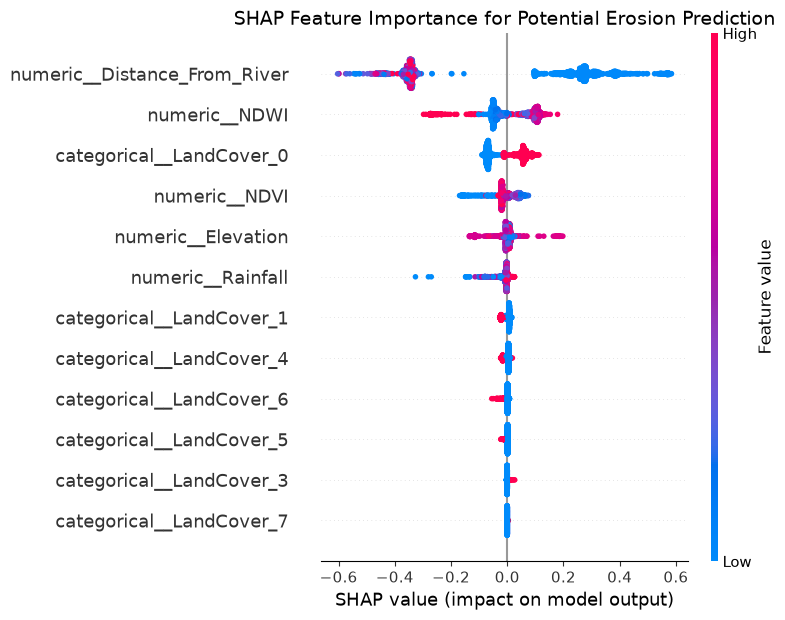

In [21]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_erosion,
    X_test,
    feature_names=feature_names.iloc[:, 0].tolist(),
    show=False
)

plt.title(
    "SHAP Feature Importance for Potential Erosion Prediction",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [22]:
mean_abs_shap = np.abs(shap_values_erosion).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names.iloc[:, 0],
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(shap_importance)

,Feature,Mean_Absolute_SHAP
4,numeric__Distance_From_River,0.317947
1,numeric__NDWI,0.074651
5,categorical__LandCover_0,0.062558
0,numeric__NDVI,0.028790
2,numeric__Elevation,0.013919
3,numeric__Rainfall,0.010585
6,categorical__LandCover_1,0.009688
8,categorical__LandCover_4,0.006430
10,categorical__LandCover_6,0.002608
9,categorical__LandCover_5,0.001558


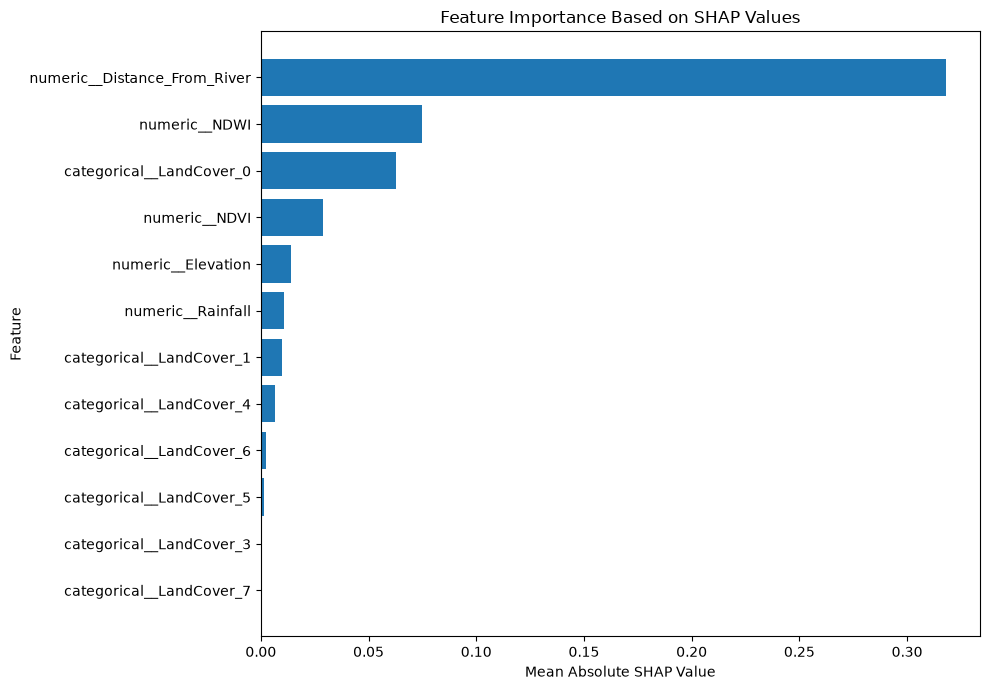

In [23]:
plt.figure(figsize=(10, 7))

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean_Absolute_SHAP"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Feature Importance Based on SHAP Values")

plt.tight_layout()
plt.show()

In [24]:
shap_importance.to_csv(
    "../results/random_forest_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


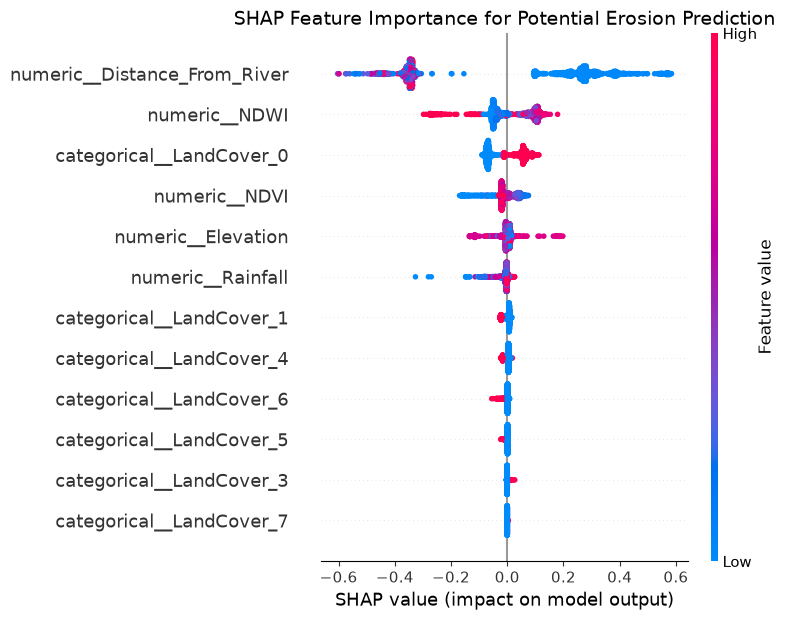

SHAP summary plot saved successfully.


In [25]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_erosion,
    X_test,
    feature_names=feature_names.iloc[:, 0].tolist(),
    show=False
)

plt.title(
    "SHAP Feature Importance for Potential Erosion Prediction",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "../results/random_forest_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP summary plot saved successfully.")

<Figure size 1000x600 with 0 Axes>

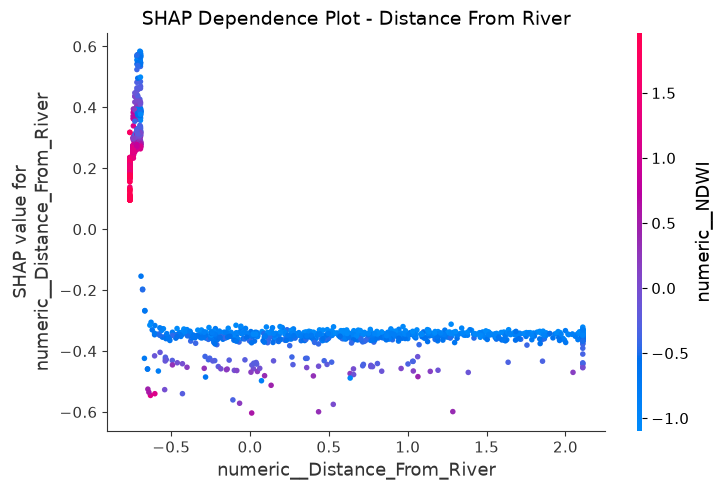

In [26]:
# ============================================
# 10. SHAP DEPENDENCE PLOT - DISTANCE FROM RIVER
# ============================================

plt.figure(figsize=(10, 6))

shap.dependence_plot(
    "numeric__Distance_From_River",
    shap_values_erosion,
    X_test,
    feature_names=feature_names.iloc[:, 0].tolist(),
    show=False
)

plt.title(
    "SHAP Dependence Plot - Distance From River",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [27]:
print(type(shap_values_erosion))

<class 'numpy.ndarray'>


SHAP feature importance plot saved successfully.


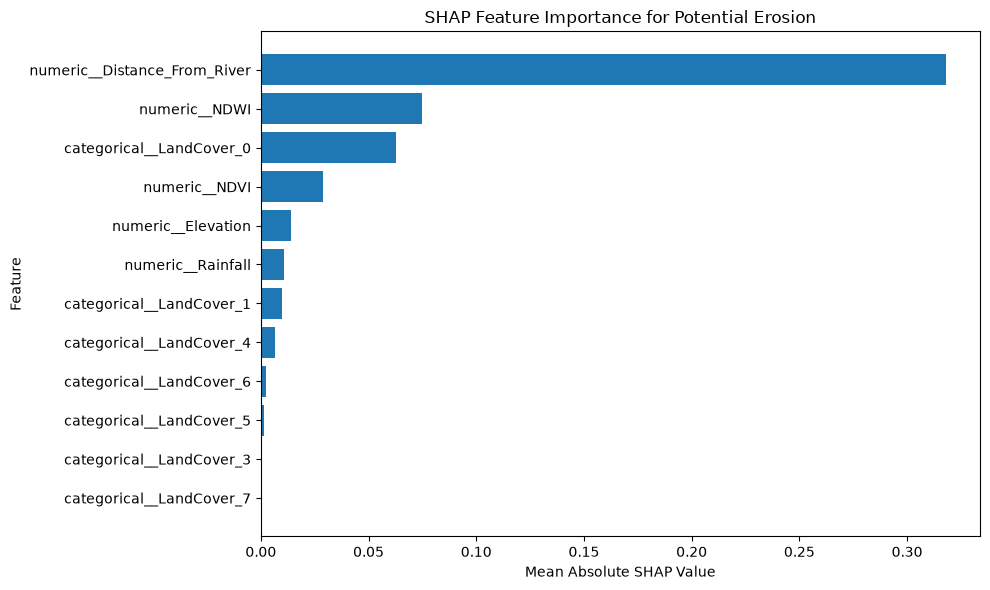

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved SHAP feature importance
shap_importance = pd.read_csv(
    "../results/random_forest_shap_feature_importance.csv"
)

# Sort by importance
shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

# Create figure
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance for Potential Erosion")

plt.tight_layout()

# Save BEFORE showing
plt.savefig(
    "../results/random_forest_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

print("SHAP feature importance plot saved successfully.")

plt.show()